# PMID36973557_NatBiotechnol2023_T-cell-depleted

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter("ignore", category=NumbaDeprecationWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
import os
import sys
import numpy as np
import pandas as pd

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import scanpy as sc
import decoupler as dc

In [6]:
import scmagnify as scm
from scmagnify.settings import settings
import scmagnify.logging as logg

In [7]:
import session_info
session_info.show()

/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


## Configurations

In [8]:
%matplotlib inline
scm.settings.verbosity = 4
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=100,
    facecolor="white",
    frameon=False,
) 

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "Arial"
plt.rcParams["image.cmap"] = "Spectral_r"
plt.rcParams['grid.alpha'] = 0

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["text.usetex"] = False

In [10]:
# dirPjtHome = "/csb3/project/chenxufeng/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted/"
dirPjtHome = "/home/chenxufeng/picb_cxf/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted/"
os.chdir(dirPjtHome)

In [11]:
workDir = os.path.join(dirPjtHome, "scmagnify_wd")
scm.set_workspace(workDir)

workspace: /home/chenxufeng/picb_cxf/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted/scmagnify_wd/
├── data
├── models
├── tmpfiles
└── figures

In [12]:
scm.set_genome(
    version="hg38",
    genomes_dir="/home/chenxufeng/picb_cxf/Ref/human/hg38/"
)

                        Genome Information                        
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Version ┃ Provider ┃ Directory                                 ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ hg38    │ UCSC     │ /home/chenxufeng/picb_cxf/Ref/human/hg38/ │
└─────────┴──────────┴───────────────────────────────────────────┘

In [13]:
fig_dir = "/home/chenxufeng/WorkSpace/scMagnify/scMagnify-figures/figures/Fig3/" 
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
data_dir = "/home/chenxufeng/WorkSpace/scMagnify/scMagnify-figures/data/Fig3/"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

## Load the Data

In [15]:
!ls ./scmagnify_wd/data/

t-cell-depleted-bm_01.h5mu
t-cell-depleted-bm_02.h5mu
t-cell-depleted-bm_Ery_02.h5mu
t-cell-depleted-bm_Ery_03.h5mu
t-cell-depleted-bm_Ery_04.h5mu
t-cell-depleted-bm_Ery_CISBPFigR_02.h5mu
t-cell-depleted-bm_Ery_final.h5mu
t-cell-depleted-bm_Ery_H13CORE_02.h5mu
t-cell-depleted-bm_Mono_02.h5mu
t-cell-depleted-bm_Mono_03.h5mu
t-cell-depleted-bm_Mono_04.h5mu
t-cell-depleted-bm_Mono_CISBPFigR_02.h5mu
t-cell-depleted-bm_Mono_final.h5mu
t-cell-depleted-bm_Mono_H13CORE_02.h5mu
t-cell-depleted-bm_NaiveB_03.h5mu
t-cell-depleted-bm_NaiveB_04.h5mu
t-cell-depleted-bm_NaiveB_CISBPFigR_02.h5mu
t-cell-depleted-bm_NaiveB_final.h5mu
t-cell-depleted-bm_NaiveB_H11CORE_02.h5mu
t-cell-depleted-bm_NaiveB_H13CORE_02.h5mu
t-cell-depleted-bm_preprocessed_NaiveB.h5mu


In [16]:
mdata = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_02.h5mu"))

In [17]:
mdata["RNA"].X = mdata["RNA"].layers["log1p_norm"].copy()

In [18]:
gdataE = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_Ery_final.h5mu"))
gdataB = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_NaiveB_final.h5mu"))
gdataM = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_Mono_final.h5mu"))

/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/mudata/_core/mudata.py:963: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/mudata/_core/mudata.py:963: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/mudata/_core/mudata.py:963: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/mudata/_core/mudata.py:963: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/mudata/_core/mudata.py:963: UserWarning: Cannot join columns wi

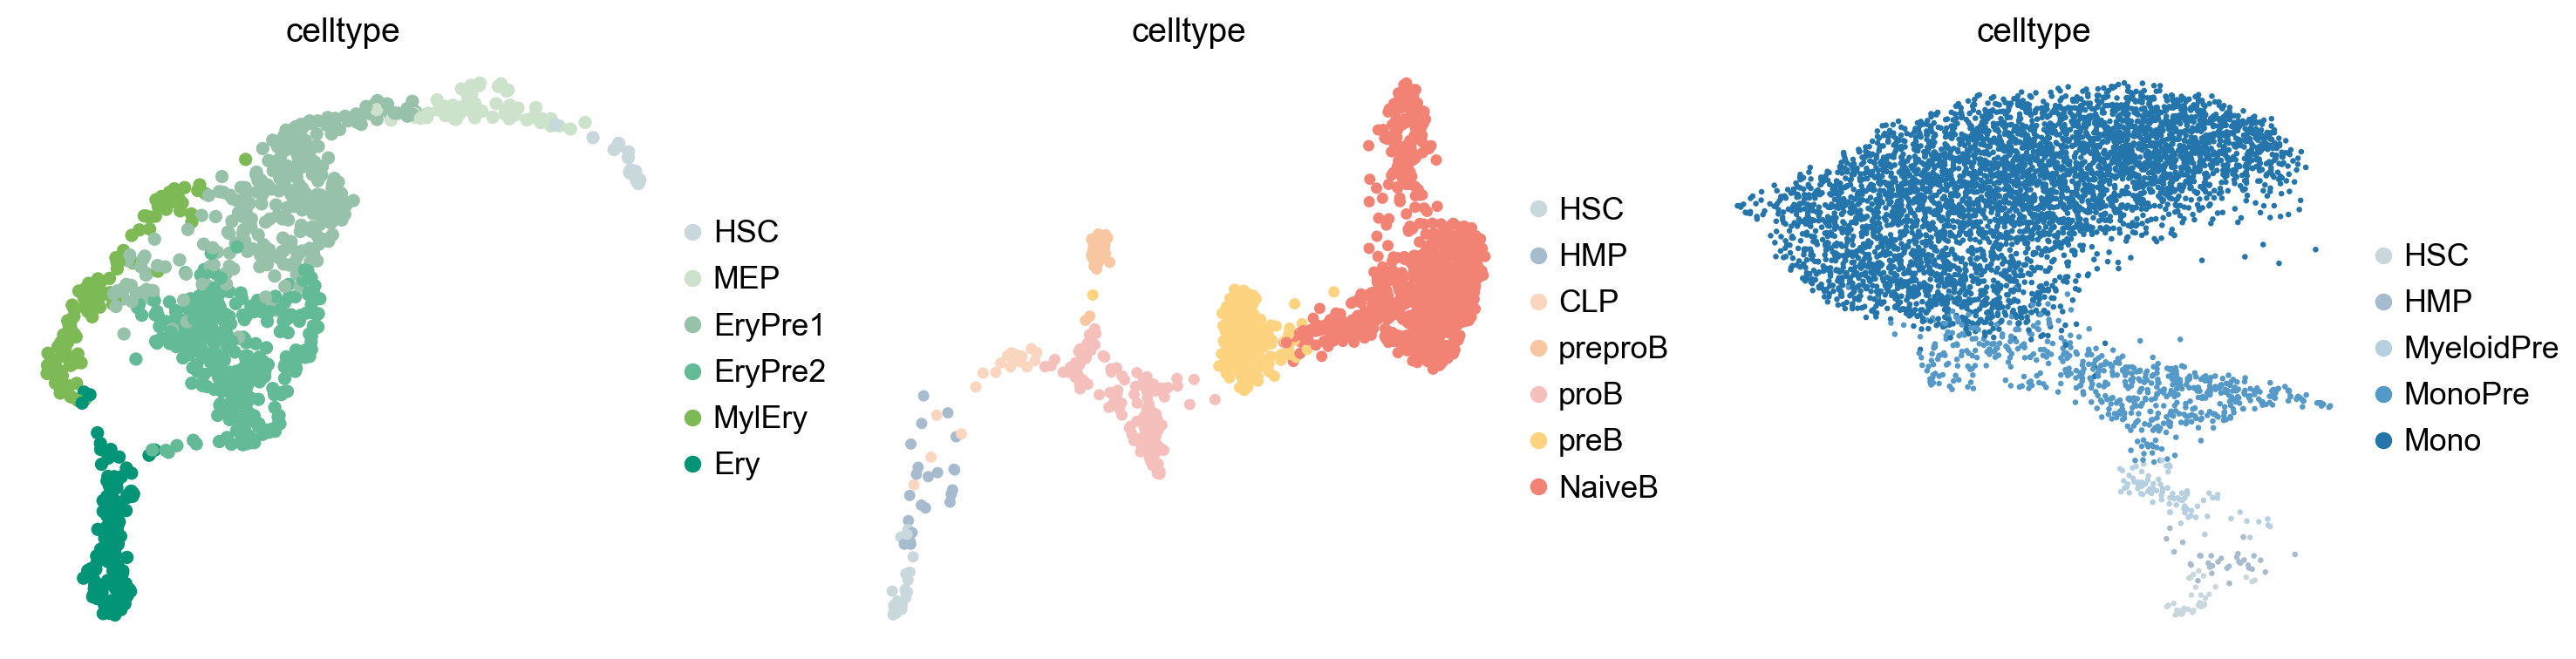

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.umap(gdataE["RNA"], color=["celltype"], ax=ax[0], show=False)
sc.pl.umap(gdataB["RNA"], color=["celltype"], ax=ax[1], show=False)
sc.pl.umap(gdataM["RNA"], color=["celltype"], ax=ax[2], show=False)
fig.tight_layout()

## Prepare the data

In [20]:
lineage_dict = {"E": gdataE, "M": gdataM, "B": gdataB}

all_tfs = set()
for gdata in lineage_dict.values():
    all_tfs.update(gdata.uns["filtered_network"]["TF"])
all_tfs = sorted(list(all_tfs))

for lineage_name, gdata in lineage_dict.items():

    gdata.filter(
        method = "quantile",
        param = 0.90,
        attri = "score",
        binarize = True,
        )

    net_df = pd.DataFrame({
        "source": gdata.uns["network"]["TF"],
        "target": gdata.uns["network"]["Target"],
        "weight": gdata.uns["network"]["signed_score"],
    })
    net_df = net_df[gdata.uns["filtered_network"]["score"] == 1]

    adata_RNA = mdata["RNA"][gdata["GRN"].obs_names, :].copy()

    dc.mt.mlm(
        adata_RNA,
        net=net_df,
        raw=False,
        layer="log1p_norm",
    )

    act_mlm = dc.pp.get_obsm(adata_RNA, "score_mlm")
    act_df_mlm = pd.DataFrame(
        act_mlm.X,
        index=act_mlm.obs_names,
        columns=act_mlm.var_names
    )

    act_df_mlm = act_df_mlm.reindex(columns=all_tfs, fill_value=0)

    gdata["GRN"].layers["mlm_estimated"] = act_df_mlm.values

                                 Network Filtered Statistics                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method(Param)        ┃ Attribute            ┃ Binarize             ┃ Filtered/Raw(Percen… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ quantile(0.9)        │ score                │ True                 │ 8610/86092 (0.10)    │
└──────────────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

                                 Network Filtered Statistics                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method(Param)        ┃ Attribute            ┃ Binarize             ┃ Filtered/Raw(Percen… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ quantile(0.9)        │ score                │ True                 │ 4102/41013 (0.10)    │
└──────────────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

                                 Network Filtered Statistics                                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Method(Param)        ┃ Attribute            ┃ Binarize             ┃ Filtered/Raw(Percen… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ quantile(0.9)        │ score                │ True                 │ 7915/79144 (0.10)    │
└──────────────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

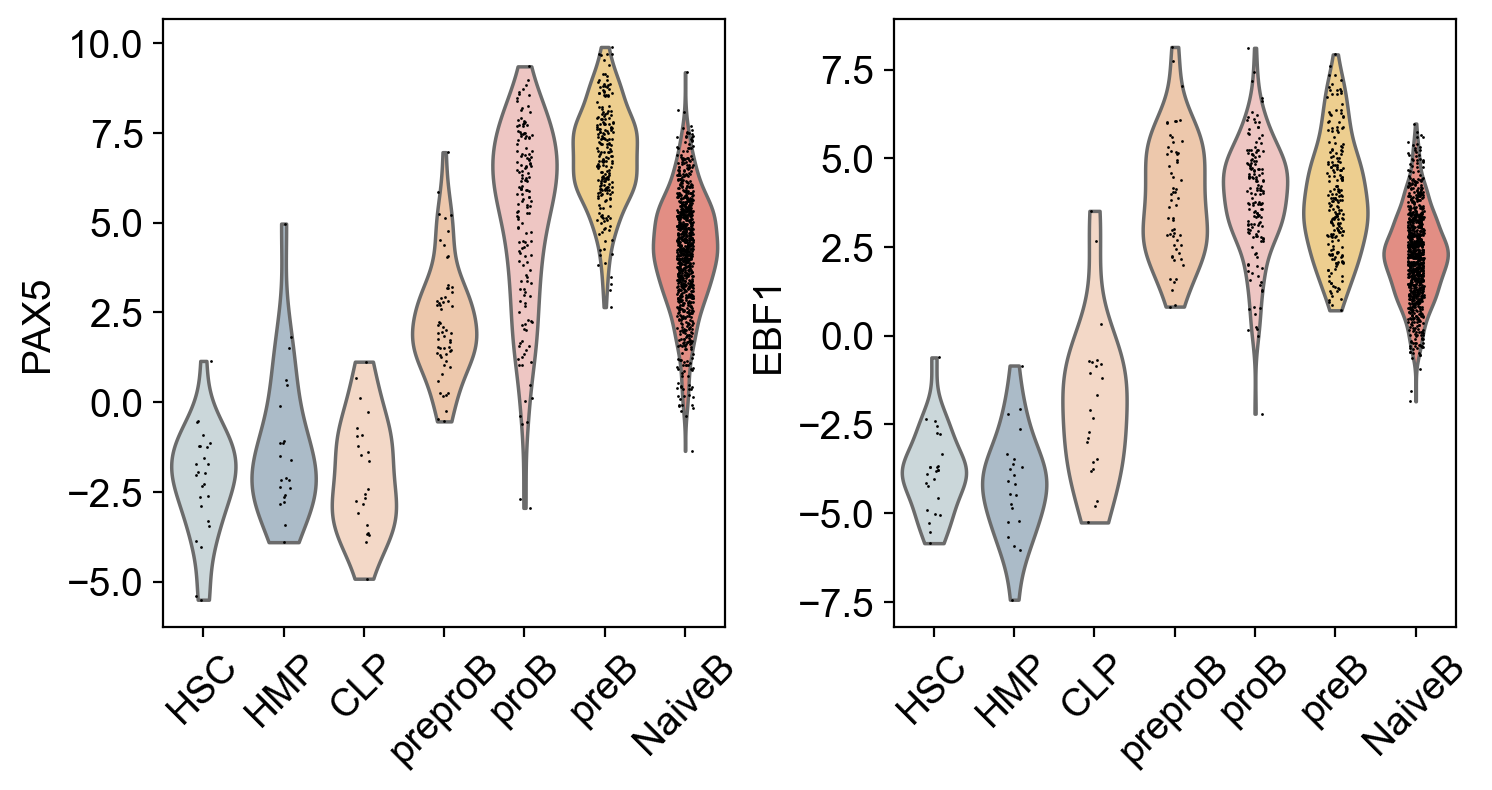

In [21]:
sc.pl.violin(gdataB["GRN"],
             use_raw=False,
                layer="mlm_estimated",
                keys=["PAX5", "EBF1"],
                groupby="celltype",
                rotation=45,)

In [22]:
lineage_dict = {"Ery": gdataE, "Mono": gdataM, "NaiveB": gdataB}
rna_df_dict = {}
mlm_df_dict = {}

stat_dict = {}

for lineage_name, gdata in lineage_dict.items():
    tf_genes = gdata["GRN"].var_names

    rna_df = pd.DataFrame(
        gdata["RNA"][:, tf_genes].X.A,
        index=gdata["RNA"].obs_names,
        columns=tf_genes
    )


    mlm_df = pd.DataFrame(
        gdata["GRN"].layers["mlm_estimated"],
        index=gdata["RNA"].obs_names,
        columns=tf_genes
    )

    stat_df = pd.DataFrame(index=tf_genes)
    stat_df["mean_mlm_estimated"] = mlm_df.mean()
    stat_df["mean_expression"] = rna_df.mean()

    rna_df_dict[lineage_name] = rna_df
    mlm_df_dict[lineage_name] = mlm_df

    stat_dict[lineage_name] = stat_df

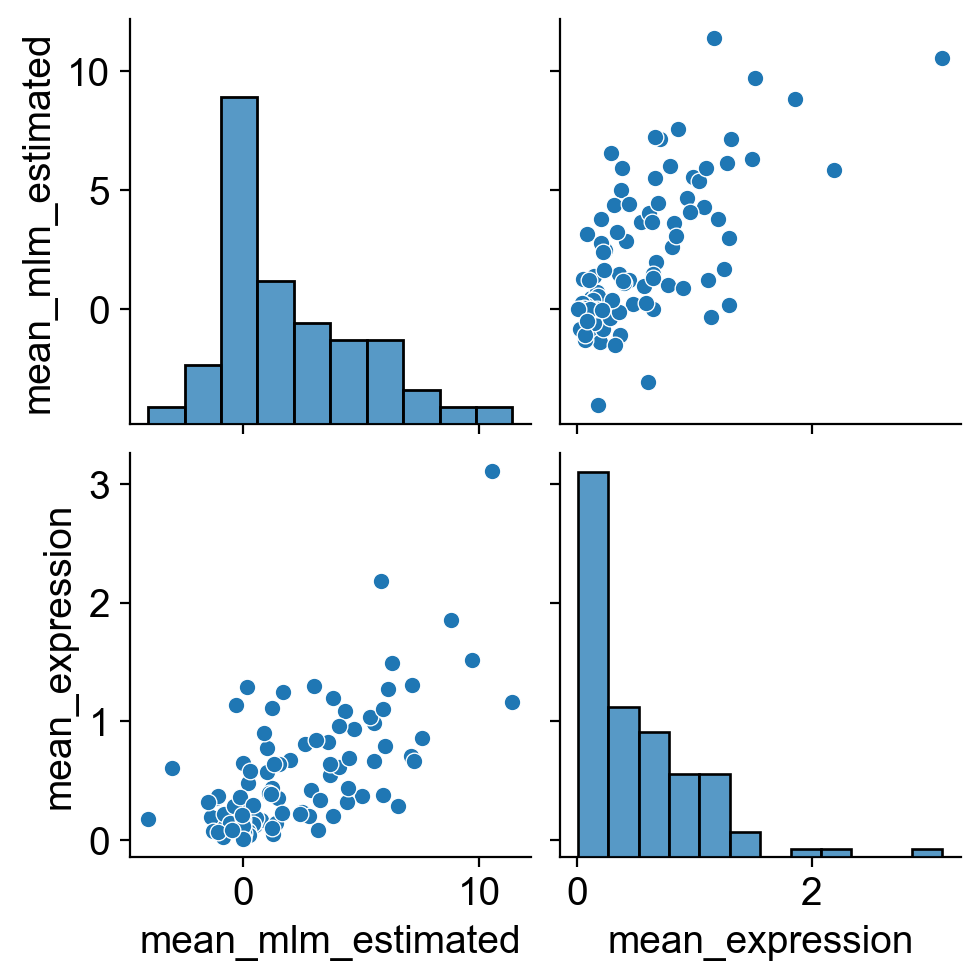

In [23]:
sns.pairplot(stat_dict["Ery"])
plt.show()

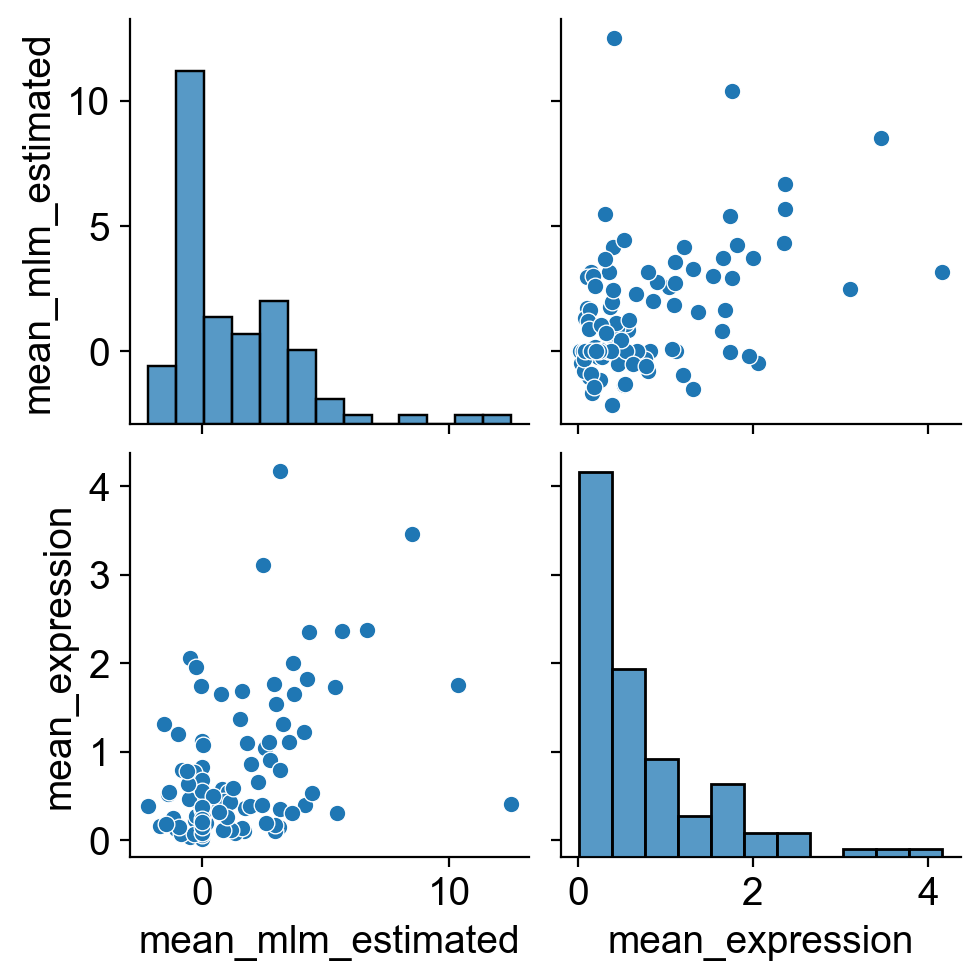

In [24]:
sns.pairplot(stat_dict["NaiveB"])
plt.show()

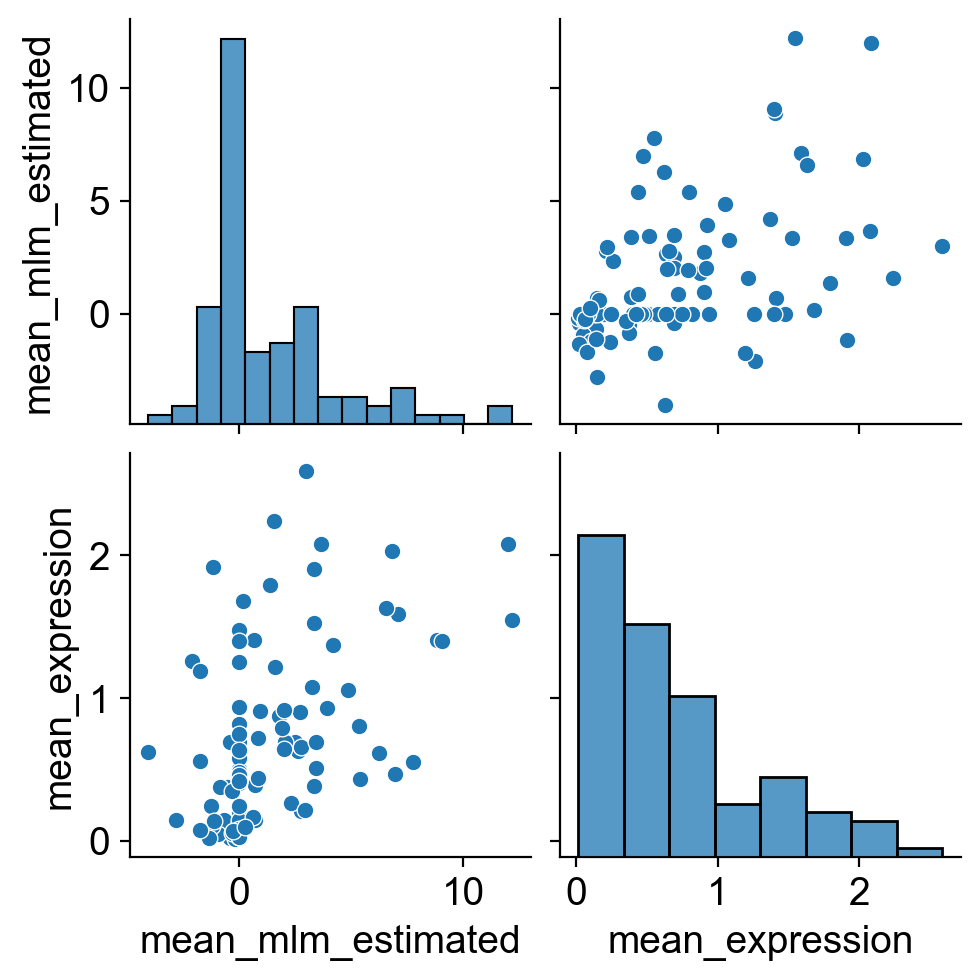

In [25]:
sns.pairplot(stat_dict["Mono"])
plt.show()

## Define TF Drivers

In [27]:
tf_dict = {
    "NaiveB": ["ERG", "EBF1", "PAX5", "IRF4", "SPIB", "BACH2", "ETS1"],
    "Mono": ["IRF8", "CEBPD", "EGR1", "FOS", "FOSB", "JUN", "KLF4"],
    "Ery": ["KLF1", "GATA2", "NFE2", "STAT5B", "KLF3", "BCL11A"]
}

## Regulation Specificity

### Helper Functions

In [28]:
from matplotlib.colors import LinearSegmentedColormap as lsc
kde_cmap = lsc.from_list( "", [(0., 'w'), (1, '#CCD7DC')], N=256)

import scipy as sp
import numpy as np
import pandas as pd
import ternary
from ternary.helpers import (
    project_point,
    planar_to_coordinates,
    simplex_iterator
)
from matplotlib.colors import cnames, to_rgb
from matplotlib import collections, lines, pyplot as plt
import seaborn as sns
import colorsys
from typing import List


def ternary_kde(
    points,
    tax,
    n_levels=10,
    cmap="viridis",
    outline=False,
    bw_method='scott',
):
    # Project to 2D simplex
    simplex_points = np.apply_along_axis(project_point, 0, points)

    # Fit density model to 2D projection
    kde = sp.stats.gaussian_kde(simplex_points, bw_method=bw_method)

    # Evaluate density on triangular grid
    n = 100
    tri_grid = np.array(list(simplex_iterator(n))).T
    simplex_grid = np.apply_along_axis(project_point, 0, tri_grid)/n
    densities = kde(simplex_grid)
    levels = np.linspace(
        np.percentile(densities, 5), 
        np.percentile(densities, 95), 
        n_levels,
    ) 
    tax.ax.tricontourf(
        simplex_grid[0], simplex_grid[1], 
        densities, levels=levels, cmap=cmap,
        extend="both"
    )
    if outline:
        tax.ax.tricontour(
            simplex_grid[0], simplex_grid[1], 
            densities, levels=levels,
            colors=[[0,0,0,0.25]]+[[0,0,0,0.25]]*4,
            linewidths=[0.25]+[0.25]*4
        )


def format_tax(
    tax, 
    labels,
    fontsize,
    tick_width,
    boundary_width,
    pad,
):
    tax.gridlines(
        color="gray", lw=tick_width, linestyle='--', alpha=0.5, multiple=0.5
    )
    tax.ticks(
        axis='lbr', lw=tick_width, fontsize=fontsize, tick_formats='%.1f',
        offset=0.05, multiple=1.0,
    )
    tax.boundary(linewidth=boundary_width, zorder=4)
    tax.clear_matplotlib_ticks()
    tax.get_axes().axis('off')


def plot_ternary(
    points,
    cmap,
    titles,
    ax,
    n_pts: int = 1000,
):
    _, tax = ternary.figure(ax=ax)
    ternary_kde(
        points.T, 
        tax, 
        n_levels=9,
        cmap=cmap, 
        outline=True,
        bw_method=0.3,
    )
    idx = np.random.choice(points.shape[0], n_pts)
    tax.scatter(points[idx], s=20, lw=1, color="white", alpha=0.33)
    format_tax(
        tax=tax, 
        labels=titles,
        fontsize=12,
        tick_width=0.5,
        boundary_width=1,
        pad=2,
    )


def lighten_color(color, amount: float):
    # Lookup color in matplotlib named colors
    try:
        color = cnames[color]
    except:
        pass
    h, l, s = colorsys.rgb_to_hls(*to_rgb(color))
    color = colorsys.hls_to_rgb(h, 1 - amount * (1 - l), s)
    return color


def patch_violinplot(ax):
    children = ax.get_children()
    i = 0
    for n in range(0, len(children), 4):
        art = children[n: n+4]
        is_violin = len(art) == 4
        is_violin &= isinstance(art[0], collections.PolyCollection)
        is_violin &= all([isinstance(a, lines.Line2D) for a in art[1:]])
        if is_violin:
            violin, q1, q2, q3 = art
            c = violin.get_facecolor()
            if i%2==1: c = lighten_color(c, 0.5)
            violin.set_facecolor(c)
            violin.set_edgecolor(c)
            violin.set_linewidth(0.1)
            q2.set_linestyle('solid')
            q2.set_linewidth(0.5)
            q2.set_solid_capstyle('butt')
            for q in [q1, q3]:
                q.set_alpha(0)
            i += 1


def plot_kde(
    data: pd.DataFrame,
    row: str,
    row_order: List,
    **kwargs,
):
    # Update with default styles
    styles = dict(
        cut=0,
        common_norm=False, 
        density_norm='width',
        width=0.75,
        gap=0,
        split=True,
        fill=True,
        linewidth=0.5,
        legend=False,
        inner='quart',
    )
    kwargs.update(styles)

    # Plot KDEs
    grid = sns.FacetGrid(
        data,
        row=row,
        row_order=row_order,
        height=1.5,
        aspect=1.5,
        sharex=False,
        gridspec_kws=dict(hspace=0.5),
        despine=False,
    )
    fig = grid.map_dataframe(sns.violinplot, **kwargs)

    # Formatting
    for ax in fig.axes.flat:
        patch_violinplot(ax)
        ax.set_title('')
        ax.set_xlim(0, 1)
        ax.yaxis.set_visible(False)
        ax.spines[['top', 'left', 'right']].set_visible(False)
        ax.set_xlabel(kwargs['x'])

In [29]:
def normalize_ternary_data(df, cols):
    
    ternary_array = df[cols].values
    row_sums = ternary_array.sum(axis=1, keepdims=True)
    normed = ternary_array / (row_sums + 1e-10)
    return normed

In [30]:
def ternary_from_tf_df(
    tf_df,
    lineage_cols,
    ax=None,
    label=None,  # int, None, or list
    lineage_cmap=None,
    n_pts=1000,
    font_scale=1.0,
    noise_epsilon=0,
):
    import matplotlib.colors as mcolors
    from adjustText import adjust_text

    if lineage_cmap is None:
        lineage_cmap={"Ery": "#367D00",
                    "NaiveB": "#C86800",
                    "Mono": "#265795"}

    # Step 1: Normalize + small perturbation
    normed_points = normalize_ternary_data(tf_df, lineage_cols).copy()
    perturb = np.zeros_like(normed_points)
    perturb += (normed_points == 0) * np.random.uniform(noise_epsilon, 2 * noise_epsilon, normed_points.shape)
    perturb -= (normed_points == 1) * np.random.uniform(noise_epsilon, 2 * noise_epsilon, normed_points.shape)
    normed_points += perturb
    normed_points = np.clip(normed_points, 0, None)
    normed_points /= normed_points.sum(axis=1, keepdims=True)

    # Step 2: Assign main_lineage and specificity_score
    main_lineage_idx = normed_points.argmax(axis=1)
    tf_df["_ternary_x"] = normed_points[:, 0]
    tf_df["_ternary_y"] = normed_points[:, 1]
    tf_df["_ternary_z"] = normed_points[:, 2]
    tf_df["main_lineage"] = [lineage_cols[i] for i in main_lineage_idx]
    tf_df["specificity_score"] = normed_points.max(axis=1) - normed_points.mean(axis=1)

    # Step 3: Draw ternary background
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    plot_ternary(
        points=normed_points,
        cmap=kde_cmap,  # Base background
        titles=lineage_cols,
        ax=ax,
        n_pts=min(len(normed_points), n_pts),
    )

    corner_positions = [
        (0.5, np.sqrt(3) / 2),  # Top corner
        (1, 0),                  # Bottom-right corner
        (0, 0)                   # Bottom-left corner
    ]

    # Reoreder to (Right, Top, Left)
    corner_positions = [corner_positions[1], corner_positions[0], corner_positions[2]]

    alignments = [
        {'ha': 'center', 'va': 'bottom', 'offset_y': 0.10},  # Top
        {'ha': 'left',   'va': 'top',    'offset_y': -0.08}, # Right
        {'ha': 'right',  'va': 'top',    'offset_y': -0.05}  # Left
    ]

    alignments = [alignments[1], alignments[0], alignments[2]]

    for i, lineage in enumerate(lineage_cols):
        pos = corner_positions[i]
        align = alignments[i]
        ax.text(
            pos[0], pos[1] + align['offset_y'], lineage,
            fontsize=15 * font_scale,
            fontweight='bold',
            color=lineage_cmap.get(lineage, 'black'),
            horizontalalignment=align['ha'],
            verticalalignment=align['va'],
        )

    # Step 4: Add colored scatter
    simplex_points = np.apply_along_axis(project_point, 1, normed_points)
    norm_scores = tf_df["specificity_score"].values
    norm_scores = (norm_scores - norm_scores.min()) / (norm_scores.max() - norm_scores.min() + 1e-6)

    point_colors = []
    # for i, row in tf_df.iterrows():
    #     base_color = lineage_cmap.get(row["main_lineage"], "#cccccc")
    #     rgb = mcolors.to_rgb(base_color)
    #     color = colorsys.rgb_to_hls(*rgb)
    #     darkened = colorsys.hls_to_rgb(color[0], 0.75 - 0.5 * norm_scores[i], color[2])
    #     point_colors.append(darkened)

    gray_rgb = np.array([0.6, 0.6, 0.6])  
    for idx, (i, row) in enumerate(tf_df.iterrows()):
        base_color = lineage_cmap.get(row["main_lineage"], "#cccccc")
        base_rgb = np.array(mcolors.to_rgb(base_color))
        score = norm_scores[idx]
        mixed_rgb = gray_rgb * (1 - score) + base_rgb * score
        point_colors.append(tuple(mixed_rgb))

    ax.scatter(simplex_points[:, 0], simplex_points[:, 1],
               s=25, lw=0.2, edgecolors="black", color=point_colors, alpha=1)

    # Step 5: Add labels
    texts = []
    if isinstance(label, int):
        for lineage in lineage_cols:
            df_top = (
                tf_df[tf_df["main_lineage"] == lineage]
                .sort_values("specificity_score", ascending=False)
                .head(label)
            )
            for gene, row in df_top.iterrows():
                x0, y0 = project_point([row["_ternary_x"], row["_ternary_y"], row["_ternary_z"]])
                label_x = x0 + 0.03
                label_y = y0 + 0.03
                text = ax.text(
                    label_x, label_y, gene,
                    fontsize=8 * font_scale, color="black",
                    fontstyle="normal",
                    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3", alpha=1)
                )
                texts.append(text)
                # ax.plot([x0, label_x], [y0, label_y], color="black", linestyle="--", linewidth=0.5)
                
    elif isinstance(label, list):
        df_top = tf_df.loc[tf_df.index.intersection(label)]
        for gene, row in df_top.iterrows():
            x0, y0 = project_point([row["_ternary_x"], row["_ternary_y"], row["_ternary_z"]])
            label_x = x0 + 0.03
            label_y = y0 + 0.03
            text = ax.text(
                label_x, label_y, gene,
                fontsize=8 * font_scale, color="black",
                fontstyle="normal",
                bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3", alpha=1)
            )
            texts.append(text)
            ax.plot([x0, label_x], [y0, label_y], color="black", linestyle="--", linewidth=1)

    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='black', lw=0))

    return ax


### Simulation Data

/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


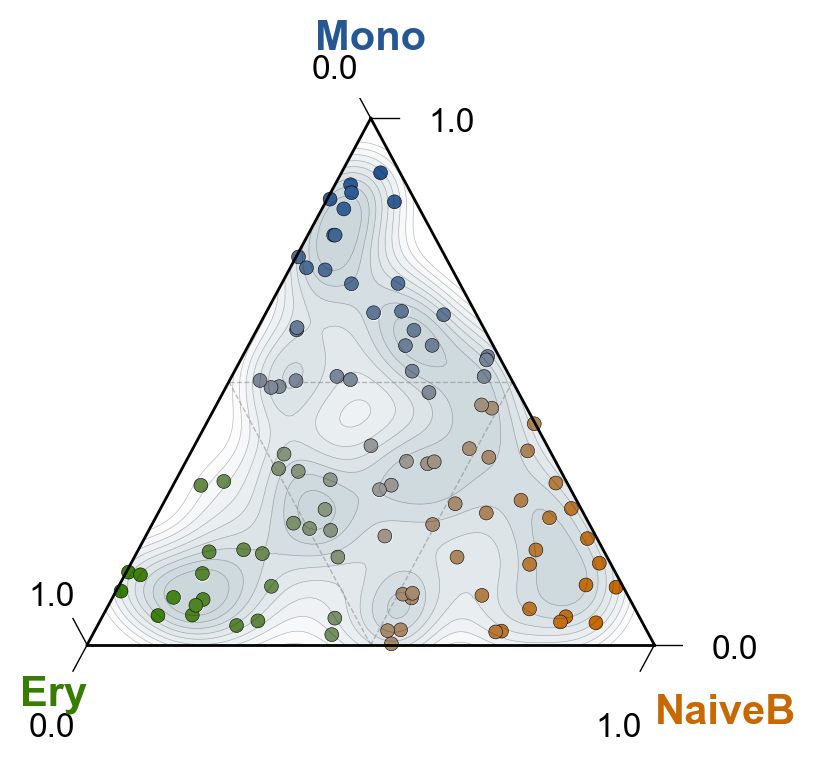

In [31]:
def generate_random_ternary(n=100, seed=42):
    np.random.seed(seed)
    raw = np.random.dirichlet([1, 1, 1], size=n) 
    return raw  # shape: (n, 3)

points = generate_random_ternary(100)

points_df = pd.DataFrame(points, columns=['Ery', 'NaiveB', 'Mono'])

ax = ternary_from_tf_df(points_df, 
                         [ 'NaiveB', 'Mono', 'Ery'], 
                         n_pts=1000, 
                         lineage_cmap={"NaiveB": "#C86800",
                                       "Mono": "#265795",
                                       "Ery": "#367D00",},)
plt.show()


### Expression Specificity

In [32]:
exp_df_norm = pd.DataFrame(index = gdataE["GRN"].var_names)
exp_df_norm["Ery"] = stat_dict["Ery"]["mean_expression"]
exp_df_norm["NaiveB"] = stat_dict["NaiveB"]["mean_expression"]
exp_df_norm["Mono"] =  stat_dict["Mono"]["mean_expression"]
exp_df_norm = exp_df_norm.div(exp_df_norm.sum(axis=1), axis=0)

In [33]:
exp_df_norm

,Ery,NaiveB,Mono
AHR,0.111024,0.178593,0.710383
ARID5B,0.033784,0.690304,0.275913
ATF2,0.377250,0.339201,0.283549
BACH1,0.227224,0.306921,0.465855
BACH2,0.051373,0.903026,0.045601
...,...,...,...
ZEB1,0.316265,0.647410,0.036325
ZKSCAN1,0.303198,0.341910,0.354892
ZNF121,0.476232,0.293830,0.229939
ZNF331,0.275154,0.436540,0.288306


/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)
2025-10-09 14:09:15 | [INFO] maxp pruned
2025-10-09 14:09:15 | [INFO] LTSH dropped
2025-10-09 14:09:15 | [INFO] cmap pruned
2025-10-09 14:09:15 | [INFO] kern dropped
2025-10-09 14:09:15 | [INFO] post pruned
2025-10-09 14:09:15 | [INFO] PCLT dropped
2025-10-09 14:09:15 | [INFO] JSTF dropped
2025-10-09 14:09:15 | [INFO] DSIG dropped
2025-10-09 14:09:15 | [INFO] GPOS pruned
2025-10-09 14:09:15 | [INFO] GSUB pruned
2025-10-09 14:09:15 | [INFO] glyf pruned
2025-10-09 14:09:15 | [INFO] Added gid0 to subset
2025-10-09 14:09:15 | [INFO] Added first four glyphs to subset
2025-10-09 14:09:15 | [INFO] Closing glyph list over 'GSUB': 16 glyphs before
2025-10-09 14:09:15 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'E', 'M', 'N', 'a', 'e', 'i'

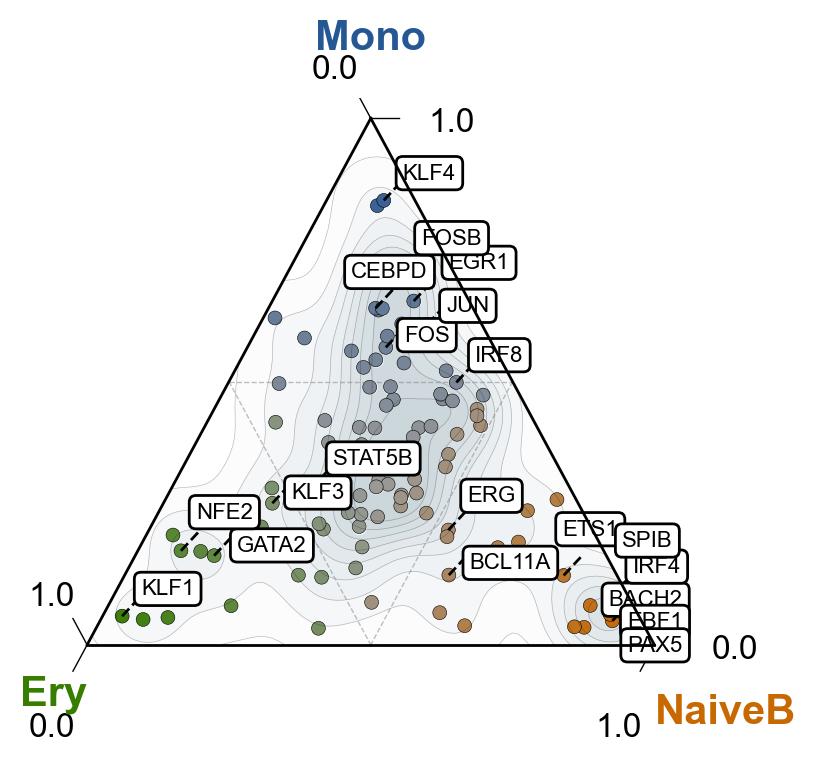

In [35]:
ax = ternary_from_tf_df(exp_df_norm, 
                         ['NaiveB', 'Mono', 'Ery'], 
                         n_pts=1000, 
                         label=[tf for tfs in tf_dict.values() for tf in tfs], 
                         lineage_cmap={"Ery": "#367D00",
                                       "NaiveB": "#C86800",
                                       "Mono": "#265795"},)
plt.savefig(os.path.join(fig_dir, "SupFig5-TF_expression_ternary.pdf"), bbox_inches='tight')
plt.show()

### TF Activity Specificity

In [36]:
mlm_df_norm = pd.DataFrame(index = gdataE["GRN"].var_names)
mlm_df_norm["Ery"] = np.abs(stat_dict["Ery"]["mean_mlm_estimated"])
mlm_df_norm["NaiveB"] = np.abs(stat_dict["NaiveB"]["mean_mlm_estimated"])
mlm_df_norm["Mono"] =  np.abs(stat_dict["Mono"]["mean_mlm_estimated"])
mlm_df_norm = mlm_df_norm.div(mlm_df_norm.sum(axis=1), axis=0)
mlm_df_norm.dropna(inplace=True)

/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)
2025-10-09 14:09:56 | [INFO] maxp pruned
2025-10-09 14:09:56 | [INFO] LTSH dropped
2025-10-09 14:09:56 | [INFO] cmap pruned
2025-10-09 14:09:56 | [INFO] kern dropped
2025-10-09 14:09:56 | [INFO] post pruned
2025-10-09 14:09:56 | [INFO] PCLT dropped
2025-10-09 14:09:56 | [INFO] JSTF dropped
2025-10-09 14:09:56 | [INFO] DSIG dropped
2025-10-09 14:09:56 | [INFO] GPOS pruned
2025-10-09 14:09:56 | [INFO] GSUB pruned
2025-10-09 14:09:56 | [INFO] glyf pruned
2025-10-09 14:09:56 | [INFO] Added gid0 to subset
2025-10-09 14:09:56 | [INFO] Added first four glyphs to subset
2025-10-09 14:09:56 | [INFO] Closing glyph list over 'GSUB': 16 glyphs before
2025-10-09 14:09:56 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'E', 'M', 'N', 'a', 'e', 'i'

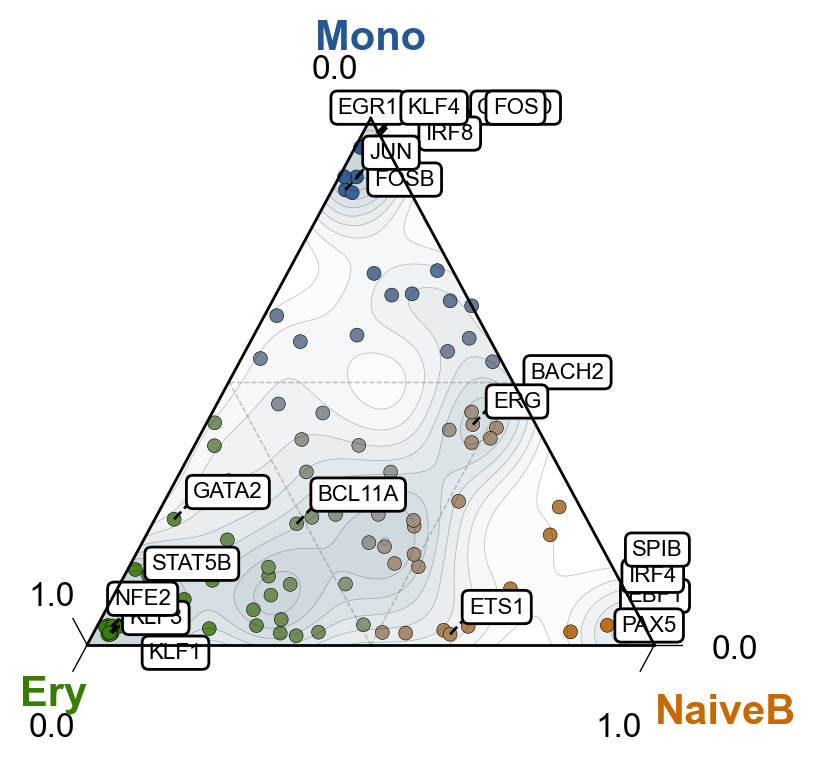

In [38]:
ax = ternary_from_tf_df(mlm_df_norm, 
                         [ 'NaiveB', 'Mono', 'Ery'], 
                         n_pts=1000, label=[tf for tfs in tf_dict.values() for tf in tfs],  
                         noise_epsilon=0.02)
plt.savefig(os.path.join(fig_dir, "SupFig5-TF_activity_ternary.pdf"), bbox_inches='tight')
plt.show()

### Regulation Specificity

In [39]:
mlm_exp_df_norm = (mlm_df_norm[["Ery", "NaiveB", "Mono"]] + exp_df_norm[["Ery", "NaiveB", "Mono"]]) / 2
mlm_exp_df_norm.dropna(inplace=True)

/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)
2025-10-09 14:10:31 | [INFO] maxp pruned
2025-10-09 14:10:31 | [INFO] LTSH dropped
2025-10-09 14:10:31 | [INFO] cmap pruned
2025-10-09 14:10:31 | [INFO] kern dropped
2025-10-09 14:10:31 | [INFO] post pruned
2025-10-09 14:10:31 | [INFO] PCLT dropped
2025-10-09 14:10:31 | [INFO] JSTF dropped
2025-10-09 14:10:31 | [INFO] DSIG dropped
2025-10-09 14:10:31 | [INFO] GPOS pruned
2025-10-09 14:10:31 | [INFO] GSUB pruned
2025-10-09 14:10:31 | [INFO] glyf pruned
2025-10-09 14:10:31 | [INFO] Added gid0 to subset
2025-10-09 14:10:31 | [INFO] Added first four glyphs to subset
2025-10-09 14:10:31 | [INFO] Closing glyph list over 'GSUB': 16 glyphs before
2025-10-09 14:10:31 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'E', 'M', 'N', 'a', 'e', 'i'

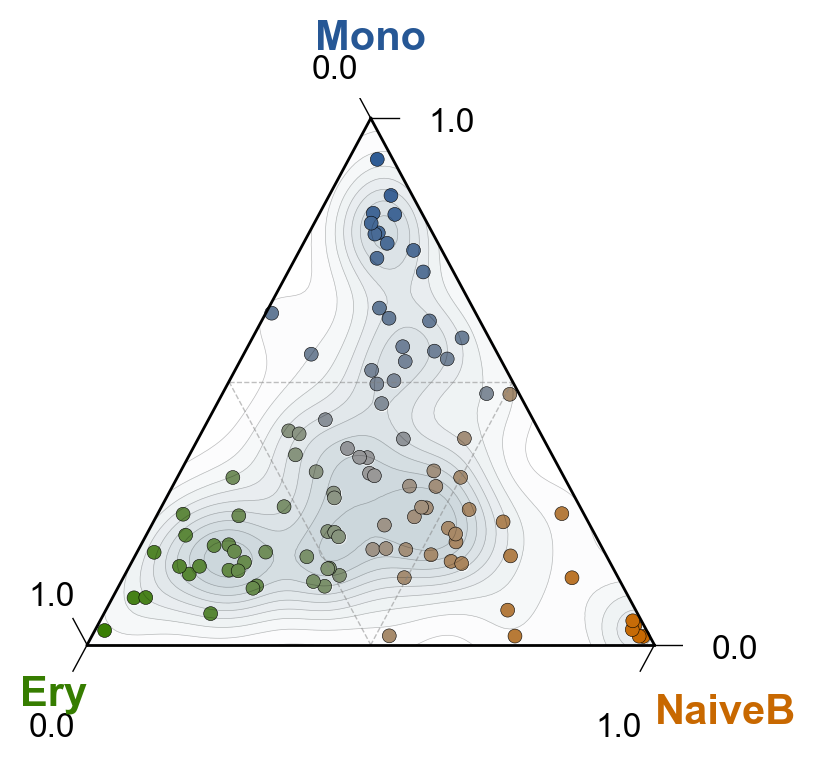

In [40]:
ax = ternary_from_tf_df(mlm_exp_df_norm, 
                         ['NaiveB', 'Mono', 'Ery'],  
                         n_pts=1000, 
                         noise_epsilon=0.02)
plt.savefig(os.path.join(fig_dir, "Fig3b-ternary_mlm_exp_t_cell-raw.pdf"), bbox_inches='tight')

/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)
2025-10-09 14:10:32 | [INFO] maxp pruned
2025-10-09 14:10:32 | [INFO] LTSH dropped
2025-10-09 14:10:32 | [INFO] cmap pruned
2025-10-09 14:10:32 | [INFO] kern dropped
2025-10-09 14:10:32 | [INFO] post pruned
2025-10-09 14:10:32 | [INFO] PCLT dropped
2025-10-09 14:10:32 | [INFO] JSTF dropped
2025-10-09 14:10:32 | [INFO] DSIG dropped
2025-10-09 14:10:32 | [INFO] GPOS pruned
2025-10-09 14:10:32 | [INFO] GSUB pruned
2025-10-09 14:10:32 | [INFO] glyf pruned
2025-10-09 14:10:32 | [INFO] Added gid0 to subset
2025-10-09 14:10:32 | [INFO] Added first four glyphs to subset
2025-10-09 14:10:32 | [INFO] Closing glyph list over 'GSUB': 16 glyphs before
2025-10-09 14:10:32 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'E', 'M', 'N', 'a', 'e', 'i'

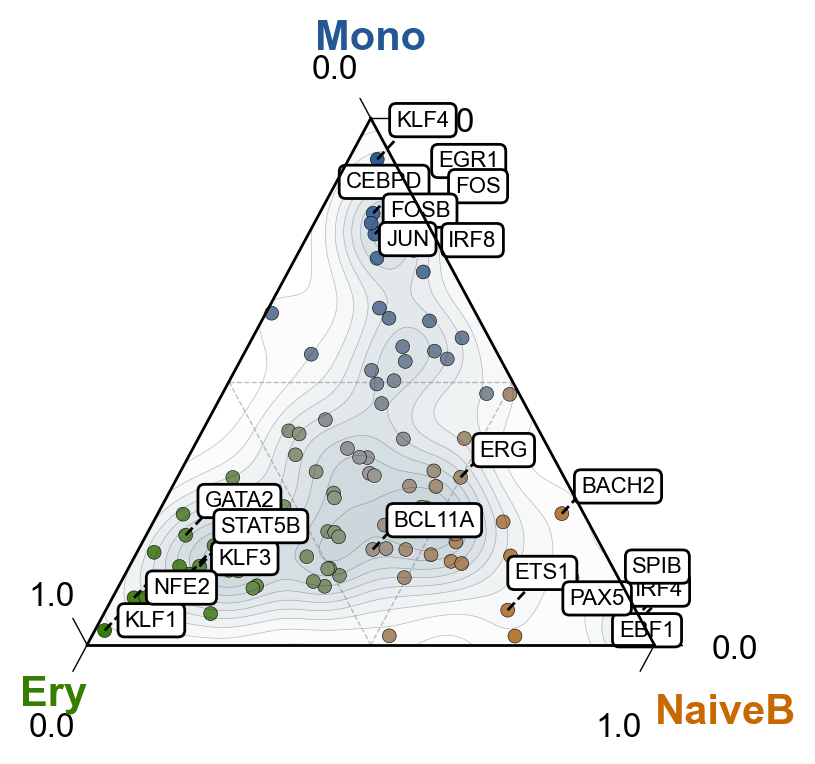

In [41]:
ax = ternary_from_tf_df(mlm_exp_df_norm, 
                         ['NaiveB', 'Mono', 'Ery'],  
                         n_pts=1000, label=[tf for tfs in tf_dict.values() for tf in tfs], 
                         noise_epsilon=0.02)

plt.savefig(os.path.join(fig_dir, "Fig3b-ternary_mlm_exp_t_cell-labeled.pdf"), bbox_inches='tight')

## Stacked bar for Target Gene Prop

In [42]:
def log2fc(x1, x2, eps=1e-8):
    x1 = np.asarray(x1, dtype=np.float64)
    x2 = np.asarray(x2, dtype=np.float64)
    abs_x1 = x1 + eps
    abs_x2 = x2 + eps
    return np.log2(abs_x1 / abs_x2)

In [43]:
target_genes = mdata["RNA"][:, mdata["RNA"].var.significant_genes].var_names

In [44]:
lineage_dict = {"Ery": gdataE, "Mono": gdataM, "NaiveB": gdataB}
target_genes = mdata["RNA"][:, mdata["RNA"].var.significant_genes].var_names
rna_target_df = pd.DataFrame(index = target_genes, columns = lineage_dict.keys())

for lineage_name, gdata in lineage_dict.items():
    lin_cells = gdata["RNA"].obs_names
    
    rna_df = pd.DataFrame(
        mdata["RNA"][gdata["RNA"].obs_names, target_genes].layers["log1p_norm"].A,
        index=gdata["RNA"].obs_names,
        columns=target_genes
    )

    rna_target_df[lineage_name] = rna_df.mean(axis=0)

In [45]:
rna_target_df

,Ery,Mono,NaiveB
NADK,0.143768,0.372814,0.194183
KCNAB2,0.084047,0.527278,0.189850
RPL22,1.067991,1.010944,0.865104
CAMTA1,0.430256,0.425828,0.491781
RERE,1.428336,1.152208,2.077666
...,...,...,...
MT-ND4L,2.562649,2.610472,2.276965
MT-ND4,4.176109,4.312686,3.921028
MT-ND5,3.577939,3.697538,2.938240
MT-ND6,0.766805,0.871704,0.496319


In [46]:
lineages = list(stat_dict.keys())
diff_target_df = pd.DataFrame(index = target_genes, columns = lineages)

for lineage in lineages:

    current_df = rna_target_df[lineage]
    others = [l for l in lineages if l != lineage]
    other_df_1, other_df_2 = rna_target_df[others[0]], rna_target_df[others[1]]

    mean_other_exp = (other_df_1 + other_df_2) / 2

    diff_target_df[lineage] = log2fc(current_df, mean_other_exp)

In [47]:
diff_target_df

,Ery,Mono,NaiveB
NADK,-0.979598,1.141643,-0.411582
KCNAB2,-2.092968,1.944932,-0.687079
RPL22,0.187203,0.064791,-0.264900
CAMTA1,-0.092683,-0.114552,0.200261
RERE,-0.177143,-0.605425,0.687289
...,...,...,...
MT-ND4L,0.068558,0.109419,-0.183923
MT-ND4,0.020616,0.091175,-0.114328
MT-ND5,0.108863,0.182539,-0.308090
MT-ND6,0.164839,0.464914,-0.723043


In [48]:
rna_target_df_div = rna_target_df.div(rna_target_df.sum(axis=1), axis=0)

In [49]:
rna_target_df_div

,Ery,Mono,NaiveB
NADK,0.202272,0.524525,0.273203
KCNAB2,0.104904,0.658131,0.236964
RPL22,0.362764,0.343387,0.293849
CAMTA1,0.319213,0.315928,0.364859
RERE,0.306628,0.247350,0.446022
...,...,...,...
MT-ND4L,0.343976,0.350395,0.305629
MT-ND4,0.336516,0.347522,0.315962
MT-ND5,0.350307,0.362017,0.287676
MT-ND6,0.359188,0.408325,0.232487


In [50]:
def classify_lineage(row, threshold=0.4, margin=0.2):
    vals = row.values
    max_idx = np.argmax(vals)
    max_val = vals[max_idx]
    sorted_vals = np.sort(vals)
    second_max_val = sorted_vals[-2]

    if max_val > threshold and (max_val - second_max_val) > margin:
        return row.index[max_idx]
    else:
        return "None"

In [51]:
rna_target_df_div = rna_target_df.div(rna_target_df.sum(axis=1), axis=0)
rna_target_df_div["lineage"] = rna_target_df_div.apply(classify_lineage, axis=1)
rna_target_df_div["lineage"].value_counts()

lineage
None      1623
Mono       669
Ery        561
NaiveB     428
Name: count, dtype: int64

In [52]:
rna_target_df_div.head()

,Ery,Mono,NaiveB,lineage
NADK,0.202272,0.524525,0.273203,Mono
KCNAB2,0.104904,0.658131,0.236964,Mono
RPL22,0.362764,0.343387,0.293849,None
CAMTA1,0.319213,0.315928,0.364859,None
RERE,0.306628,0.247350,0.446022,None


In [53]:
def classify_lineage_by_logfc(row, min_diff=0.2, min_fc=0.4):
    max_val = row.max()
    median_val = row.median()
    if (max_val - median_val < min_diff) or (max_val < min_fc):
        return "None"
    return row.idxmax()

In [54]:
diff_target_df["lineage"] = diff_target_df.apply(classify_lineage_by_logfc, axis=1)
diff_target_df["lineage"].value_counts()

lineage
Mono      1032
Ery        914
NaiveB     726
None       609
Name: count, dtype: int64

In [55]:
# target_lineage = rna_target_df_div["lineage"]
target_lineage = diff_target_df["lineage"]

In [56]:
tf_lineage_count_dict = {}

for lineage, gdata in lineage_dict.items():
    edge_df = gdata.uns["filtered_network"][gdata.uns["filtered_network"]["score"] == 1][["TF", "Target"]].copy()
    edge_df = edge_df[edge_df["Target"].isin(target_lineage.index)]
    edge_df = edge_df.merge(target_lineage, left_on="Target", right_index=True, how="left")

    tf_lineage_count = edge_df.groupby(['TF', 'lineage']).size().unstack(fill_value=0)

    tf_lineage_count_dict[lineage] = tf_lineage_count

In [57]:
final_data = {
    'TF': [],
    'Ery': [],
    'Mono': [],
    'NaiveB': [],
    'None': []
}


for lineage, tf_list in tf_dict.items():
    df = tf_lineage_count_dict[lineage]
    temp_data = {
        'TF': [],
        'Ery': [],
        'Mono': [],
        'NaiveB': [],
        'None': [],
        'Total': []
    }

    for tf in tf_list:
        if tf in df.index:
            ery = df.loc[tf, 'Ery']
            mono = df.loc[tf, 'Mono']
            naiveb = df.loc[tf, 'NaiveB']
            none = df.loc[tf, 'None']
        else:
            ery = mono = naiveb = none = 0

        temp_data['TF'].append(tf)
        temp_data['Ery'].append(ery)
        temp_data['Mono'].append(mono)
        temp_data['NaiveB'].append(naiveb)
        temp_data['None'].append(none)
        temp_data['Total'].append(ery + mono + naiveb + none)

    temp_df = pd.DataFrame(temp_data)
    temp_df = temp_df.sort_values(by='Total', ascending=False)

    for col in ['TF', 'Ery', 'Mono', 'NaiveB', 'None']:
        final_data[col].extend(temp_df[col].tolist())

stacked_bar_df = pd.DataFrame(final_data)
print(stacked_bar_df)

        TF  Ery  Mono  NaiveB  None
0      ERG  105   151     244    97
1    BACH2  129   122      91   102
2     IRF4   68    95     185    69
3     PAX5   62    80      44    33
4     EBF1   50    67      44    21
5     SPIB    8    14      22     8
6     ETS1    7     5      17     0
7     EGR1   49   124      31    32
8      JUN    7    85      17     9
9     FOSB    6    32       1    14
10    KLF4    2    27       1     2
11    IRF8    1    18       6     3
12   CEBPD    1    21       2     3
13     FOS    2    15       1     1
14  BCL11A   79    27      18    58
15    KLF3  112    30      11    27
16    KLF1   51    17       8    34
17  STAT5B   42    21      10    31
18    NFE2   49     6       0    10
19   GATA2   37     7      15     3


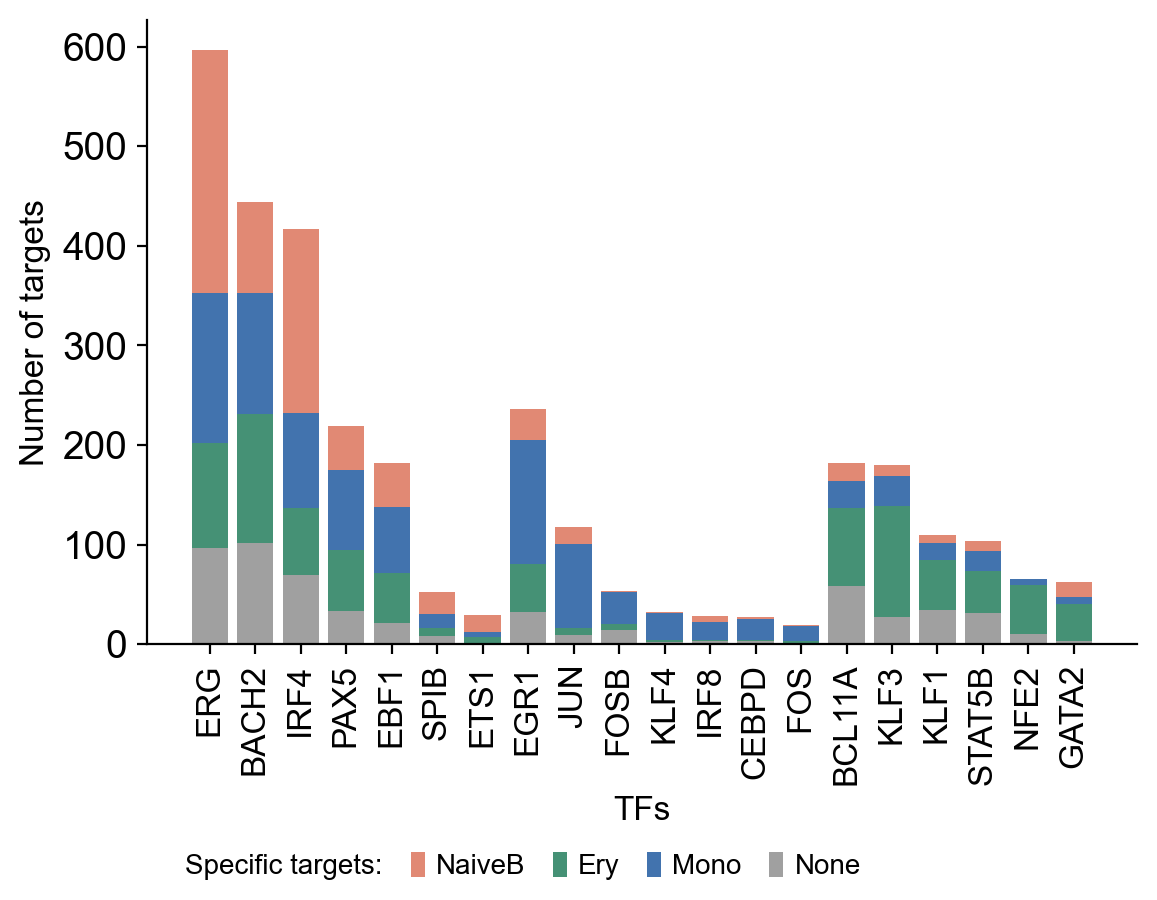

In [58]:
plt.rcParams["grid.alpha"] = 0

colors = {
    "Ery": "#459175",
    "NaiveB": "#E18974",
    "Mono": "#4273AE",
    'None': '#a0a0a0'    # Gray
}

fig, ax = plt.subplots(figsize=(6, 7)) 

bottom = np.zeros(len(stacked_bar_df))
for col in ['None', 'Ery', 'Mono',  'NaiveB']: 
    ax.bar(stacked_bar_df['TF'], stacked_bar_df[col], label=col, color=colors[col], bottom=bottom, width=0.8) 
    bottom += stacked_bar_df[col]

ax.set_xlabel('TFs', fontsize=12)
ax.set_ylabel('Number of targets', fontsize=12)
# ax.set_title('Transcription Factor Target Specificity', fontsize=14) # No explicit title in the image

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, fontsize=12)

legend_labels = ['Specific targets:', 'NaiveB', 'Ery', 'Mono', 'None']
legend_handles = [
    plt.Line2D([0], [0], color='none', label='Specific targets:'), 
    plt.Rectangle((0, 0), 1, 1, fc=colors['NaiveB']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['Ery']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['Mono']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['None'])
]

legend = ax.legend(legend_handles, legend_labels, loc='lower left', bbox_to_anchor=(0.0, -0.4), ncol=5, frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.2, 1, 1]) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add 'e' label at the top left corner as in the image
# ax.text(-0.07, 1.03, 'e', transform=ax.transAxes, fontsize=20, va='top', ha='right')

plt.show()


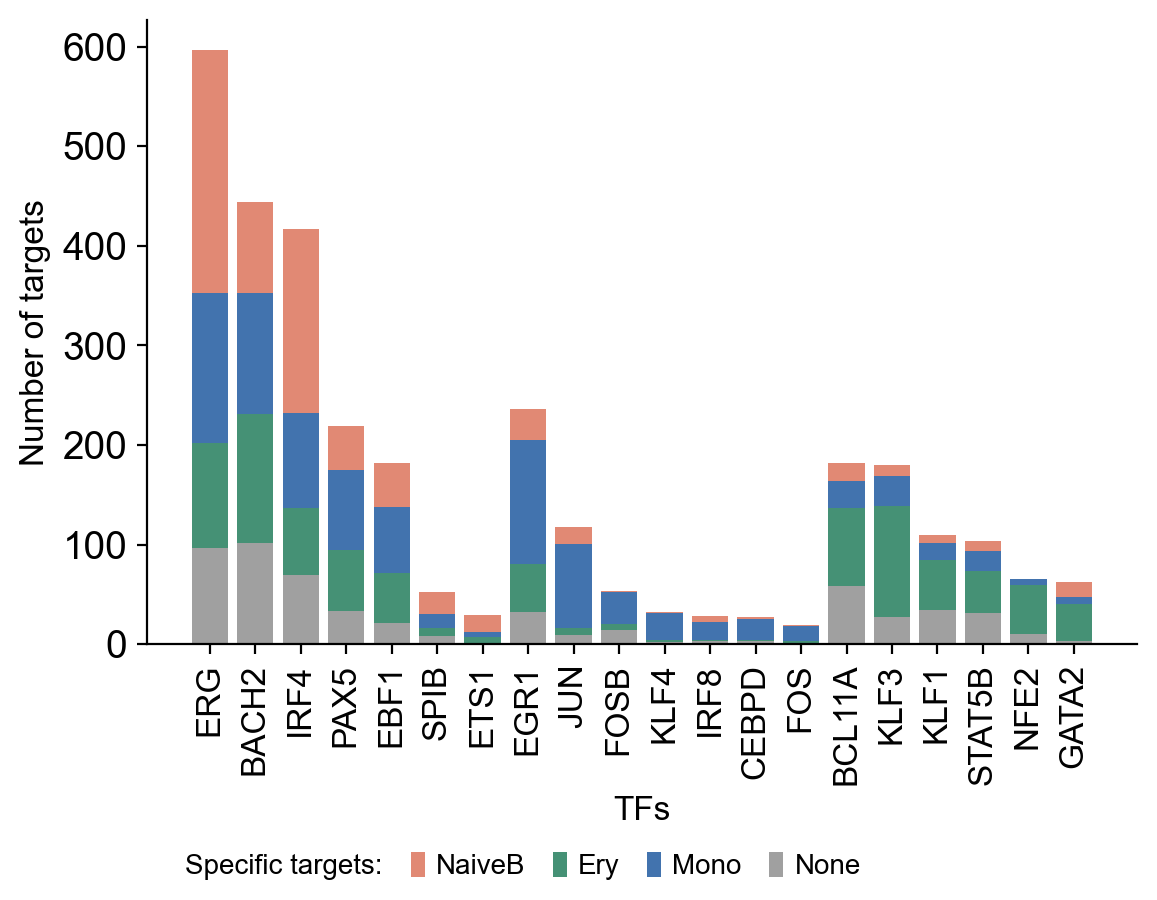

2025-10-09 14:11:38 | [INFO] maxp pruned
2025-10-09 14:11:38 | [INFO] LTSH dropped
2025-10-09 14:11:38 | [INFO] cmap pruned
2025-10-09 14:11:38 | [INFO] kern pruned
2025-10-09 14:11:38 | [INFO] post pruned
2025-10-09 14:11:38 | [INFO] PCLT dropped
2025-10-09 14:11:38 | [INFO] DSIG dropped
2025-10-09 14:11:38 | [INFO] glyf pruned
2025-10-09 14:11:38 | [INFO] Added gid0 to subset
2025-10-09 14:11:38 | [INFO] Added first four glyphs to subset
2025-10-09 14:11:38 | [INFO] Closing glyph list over 'glyf': 51 glyphs before
2025-10-09 14:11:38 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'X', 'a', 'b', 'c', 'colon', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'y', 'zero']
2025-10-09 14:11:38 | [INFO] Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 27, 29, 36, 37, 38, 39, 40, 41, 42, 43, 4

In [59]:
plt.rcParams["grid.alpha"] = 0

colors = {
    "Ery": "#459175",
    "NaiveB": "#E18974",
    "Mono": "#4273AE",
    'None': '#a0a0a0'    
}

fig, ax = plt.subplots(figsize=(6, 7)) 

bottom = np.zeros(len(stacked_bar_df))
for col in ['None', 'Ery', 'Mono',  'NaiveB']: 
    ax.bar(stacked_bar_df['TF'], stacked_bar_df[col], label=col, color=colors[col], bottom=bottom, width=0.8) 
    bottom += stacked_bar_df[col]

ax.set_xlabel('TFs', fontsize=12)
ax.set_ylabel('Number of targets', fontsize=12)
# ax.set_title('Transcription Factor Target Specificity', fontsize=14) # No explicit title in the image

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, fontsize=12)

legend_labels = ['Specific targets:', 'NaiveB', 'Ery', 'Mono', 'None']
legend_handles = [
    plt.Line2D([0], [0], color='none', label='Specific targets:'), 
    plt.Rectangle((0, 0), 1, 1, fc=colors['NaiveB']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['Ery']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['Mono']),
    plt.Rectangle((0, 0), 1, 1, fc=colors['None'])
]

legend = ax.legend(legend_handles, legend_labels, loc='lower left', bbox_to_anchor=(0.0, -0.4), ncol=5, frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.2, 1, 1]) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add 'e' label at the top left corner as in the image
# ax.text(-0.07, 1.03, 'e', transform=ax.transAxes, fontsize=20, va='top', ha='right')

plt.show()

# Save the figure if needed
fig.savefig(os.path.join(fig_dir, "Fig3c-barplot_tf_target_specificity_t_cell.pdf"), bbox_inches='tight')

## Save the Source Data

In [60]:
mlm_df_norm.to_csv(os.path.join(data_dir, "Fig3b-mlm_t_cell.csv"))
exp_df_norm.to_csv(os.path.join(data_dir, "Fig3b-exp_t_cell.csv"))
mlm_exp_df_norm.to_csv(os.path.join(data_dir, "Fig3b-mlm_exp_t_cell.csv"))

In [61]:
rna_target_df.to_csv(os.path.join(data_dir, "Fig3c-rna_target_t_cell.csv"))
diff_target_df.to_csv(os.path.join(data_dir, "Fig3c-diff_target_t_cell.csv"))
rna_target_df_div.to_csv(os.path.join(data_dir, "Fig3c-rna_target_div_t_cell.csv"))
stacked_bar_df.to_csv(os.path.join(data_dir, "Fig3c-stacked_bar_tf_target_specificity_t_cell.csv"))

In [62]:
# 1. Define the output file path
output_xlsx = os.path.join(data_dir, "SourceDataFig3bc.xlsx")

# 3. Use a loop with pd.ExcelWriter to save each dataframe to its sheet
print(f"Saving data to {output_xlsx}...")
with pd.ExcelWriter(output_xlsx, engine='xlsxwriter') as writer:
    mlm_exp_df_norm.to_excel(writer, sheet_name='Fig3b', index=False)
    stacked_bar_df.to_excel(writer, sheet_name='Fig3c', index=False)

print("File saved successfully.")

Saving data to /home/chenxufeng/WorkSpace/scMagnify/scMagnify-figures/data/Fig3/SourceDataFig3bc.xlsx...
File saved successfully.
